## In this module you will learn how to:
1. Estimate prediction models on data bigger than memory.
2. Show how different solution algorithms produce different results.

This notebook does not have an student exercise section as the use-cases are similar to standard regression/prediction in Exercise #2.



The most common type of big data in terms of size is data larger than is memory. Sometimes you may use a special system to do such analytics (e.g., Databricks or Spark), but the basics can be done easily in Python.

In this demo we show how to run a simple prediction model on data that is not all loaded into memory at once.

Notes:
1. You want to follow best practices for general computational efficiency.
2. In practice you will have to tune the system depending on your system and workflow.

We'll be using `dask` which allows working on arrays bigger than memory and it takes care of loading chunks at a time.

In [1]:
# pin dask_ml version. That needs an older version of dask: https://github.com/dask/dask-ml/issues/1012 and https://github.com/dask/dask-ml/issues/1016
!pip install dask==2025.1.0 dask_ml==2025.1.0

In [1]:
import random
import numpy as np
random.seed(2718281)
np.random.seed(2718281)

For setup, let's get some data for a simple regression relationship in dask arrays.

The default scheduler for Dask Arrays and Dataframes is the Local Threads scheduler and it doesn't require explicit creation. It doesn't, though, manage it's own memory (so if it tries to load more data than can fit in memory, the OS will either control paging or kill the process). If you want to Dask to provide a memory limit, then you can setup the local cluster using Dask Distributed. The Distributed client also provides a convenient dashboard for viewing memory as well as other memory tools like [MemorySampler](https://distributed.dask.org/en/stable/diagnosing-performance.html#distributed.diagnostics.MemorySampler).

In [10]:
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=1, memory_limit='8GiB') #Google Colab free tier has 12.6GB RAM, so we limit to 8GB to avoid OOM errors
client = Client(cluster)
#print(client) # some extra info

In [ ]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import output
    proxy_url = output.eval_js("google.colab.kernel.proxyPort(8787)")
    print(f"Click here to open the Dask Dashboard: {proxy_url}status")
else:
    print(f"Dashboard link: {client.dashboard_link}")

Dashboard link: http://127.0.0.1:8787/status


In [7]:
import dask
import dask.array as da
from dask_ml.datasets import make_regression
from dask_ml.model_selection import train_test_split

n, d = 100000, 10
n_chunks = 10

#TODO: is this seed set?
X, y, coef = make_regression(n_samples=n, n_features=d,
                           chunks=n // n_chunks, noise=50, bias=0, coef=True, random_state=0)
display(X)

from dask_ml.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0)
display(X_train)

dask.array<normal, shape=(100000, 10), dtype=float64, chunksize=(10000, 10), chunktype=numpy.ndarray>

dask.array<concatenate, shape=(90000, 10), dtype=float64, chunksize=(9000, 10), chunktype=numpy.ndarray>

In [ ]:
# If can fit in memory, this will speed things up.
persist_for_demo = False
if persist_for_demo:
  X, y = dask.persist(X, y)
  X_train, X_test, y_train, y_test = dask.persist(X_train, X_test, y_train, y_test)

## OLS
Let's first run a simple OLS. We'll compare standard `sklearn`'s implimentation against `dask`'s.

In [91]:
# Using sklearn
from sklearn.linear_model import LinearRegression as sk_LinearRegression
ols_model = sk_LinearRegression(fit_intercept=True)
ols_model.fit(X_train, y_train)

print("sklearn: Intercept:", ols_model.intercept_, "Coefficients:", ols_model.coef_,"R2:", ols_model.score(X_train,y_train))

sklearn: Intercept: 0.10872052802234472 Coefficients: [19.80382328 91.13034772 38.61733215 19.42338259 22.24285941 78.95685883
 22.75148343 14.59012718 86.18023659  8.77221771] R2: 0.9104981870299322


In [ ]:
# Using Dask-ML
from dask_ml.linear_model import LinearRegression as dask_LinearRegression

dask_ols_model = dask_LinearRegression(solver='lbfgs', solver_kwargs={"lamduh":0}, random_state=0, fit_intercept=True) #lbfgs gives very close results. The dask-glm sets lamduh=1/C, so leave C and explicitly set lambduh using solver_kwargs (overrides other) to 0. You can do this for admm, lbfgs, or proximal_grad solvers (gradient_descent and newton solvers don't use regularization)
dask_ols_model.fit(X_train, y_train) #needs these be dask arrays

print("Dask: Intercept:", dask_ols_model.intercept_, "Coefficients:", dask_ols_model.coef_, "R2:", dask_ols_model.score(X_train,y_train))

c:\Users\bquis\anaconda3\envs\dask-ml-dev\Lib\site-packages\dask\config.py:787: FutureWarning: Dask configuration key 'fuse_ave_width' has been deprecated; please use 'optimization.fuse.ave-width' instead
  warnings.warn(


Dask: Intercept: 0.10872052890299955 Coefficients: [19.80382274 91.13034683 38.6173318  19.42338321 22.24286027 78.95685905
 22.75148405 14.59012695 86.18023712  8.77221793] R2: 0.910498187029932


In [95]:
def plot_coefs(sk_coefs, dask_coefs):
    import matplotlib.pyplot as plt
    # Create the scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(sk_coefs, dask_coefs, alpha=0.6, color='blue', edgecolors='k')

    # Add a 45-degree line for reference (y=x)
    max_val = max(sk_coefs.max(), dask_coefs.max())
    min_val = min(sk_coefs.min(), dask_coefs.min())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Alignment (sk=dask)')

    plt.xlabel('Scikit-learn Coefficients')
    plt.ylabel('Dask-ML Coefficients')
    plt.title('Comparison of Coefficients: Sklearn vs Dask-ML')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

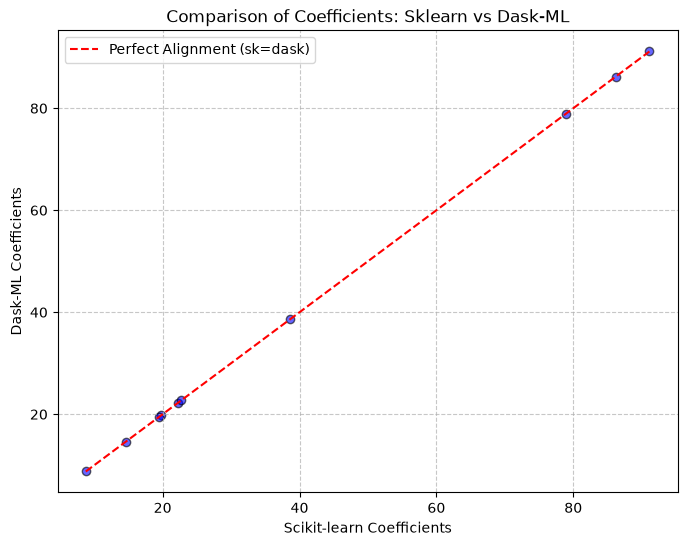

In [ ]:
# Show the results
plot_coefs(ols_model.coef_, dask_ols_model.coef_)

So far, so good!

## Penalized Linear Model
Next we think about penalized linear models and automatically picking the hyper parameter using cross validation. We do a Ridge, but you could easily switch to Lasso.

In [ ]:
ridge_alphas = (1.0, 100000.0) #for the simple model, you have to a very large alpha to move the coefficients from OLS.

In [ ]:
# First in sklearn
from sklearn.model_selection import GridSearchCV as sk_GridSearchCV
from sklearn.linear_model import Ridge as sk_Ridge

# Could've used sklearn.linear_model.RidgeCV, but this approach parallels what we can do in dask_ml.
sk_ridge_search = sk_GridSearchCV(sk_Ridge(fit_intercept=True, random_state=0), {'alpha': ridge_alphas}, scoring='r2', cv=5, refit=True)
_ = sk_ridge_search.fit(X_train, y_train)
sk_ridgecv = sk_ridge_search.best_estimator_
print("sk_ridgecv:", "alpha star:", sk_ridgecv.alpha, "Intercept:", sk_ridgecv.intercept_, "Coefficients:", sk_ridgecv.coef_, "R2 (train):", sk_ridgecv.score(X_train,y_train))

sk_ridgecv: alpha star: 1.0 Intercept: 0.1087155013201122 Coefficients: [19.80360898 91.12932602 38.61690153 19.42316497 22.24260716 78.95598857
 22.75122601 14.589978   86.17927327  8.77211209] R2 (train): 0.9104981869168609


In [ ]:
# Then in Dask-ML
from dask_ml.model_selection import GridSearchCV as dask_GridSearchCV

dask_ridge_search = dask_GridSearchCV(dask_LinearRegression(penalty='l2', fit_intercept=True, random_state=0), {'C': [1/alpha for alpha in ridge_alphas]}, scoring='r2', cv=5, refit=True)
_ = dask_ridge_search.fit(X_train, y_train)
dask_ridgecv = dask_ridge_search.best_estimator_
print("dask_ridgecv:", "alpha star:", 1/dask_ridgecv.C, "Intercept:", dask_ridgecv.intercept_, "Coefficients:", dask_ridgecv.coef_, "R2 (train):", dask_ridgecv.score(X_train,y_train))

dask_ridgecv: alpha star: 1.0 Intercept: 0.10787058348703576 Coefficients: [19.64899808 90.41788552 38.31541932 19.27152945 22.06896271 78.3395772
 22.57361027 14.47606727 85.50647721  8.70363273] R2 (train): 0.9104425357878878


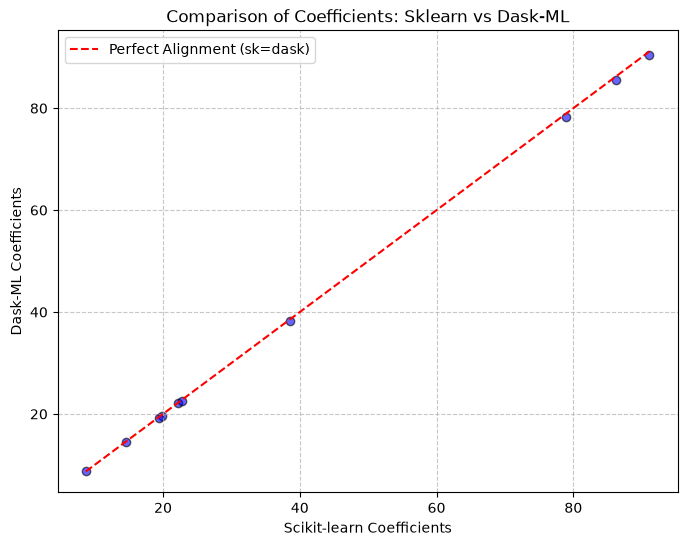

In [ ]:
# Show the results
plot_coefs(sk_ridgecv.coef_, dask_ridgecv.coef_)

Note: For `SGDRegressor` we need to make sure the features are standardized. Ours is already in this example. If you need to do it, you can either do it initially, or you can do do them in `sklearn` pipeline:

``` python
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
sgd_pipe = make_pipeline(
    StandardScaler(),
    SGDRegressor(...)
)
sgd_pipe.fit(X, y)
model = sgd_pipe.named_steps['sgdregressor'] # Extract the regressor from the pipeline to see coefficients
```

### Neural Network

We also show that a simple feed-forward neural network with no hidden layer is just a linear regression. For this, we can use `sklearn`'s Multi-Layer Perceptron (MLP) Regressor. 

In [ ]:
# First in sklearn
from sklearn.neural_network import MLPRegressor
sk_mlp = MLPRegressor(hidden_layer_sizes = [], alpha=0, solver='lbfgs', random_state=0) #activation='identity',
sk_mlp.fit(X_train, y_train)
sk_mlp_coefs = np.array([c[0] for c in sk_mlp.coefs_[0]])
print("Sklearn MLP:", "Intercept:", sk_mlp.intercepts_[0][0], "Coefficients:", sk_mlp_coefs,"R2:", sk_mlp.score(X,y))

Sklearn MLP: Intercept: 0.1087199889734241 Coefficients: [19.803824   91.13034575 38.6173305  19.42338173 22.24285887 78.95686192
 22.75148417 14.59012751 86.18023667  8.77221506] R2: 0.9109153930519287


Dask-ML doesn't provide its own `MLPRegressor`, but we can use its generic wrapper `Incremental` that can wrap any `sklearn` estimator that impliments `partial_fit` (most do) to be able to fit them incrementally. This procedure doesn't procedure nearly the identical results as we saw before, but still fairly close.

In [ ]:
# Then in Dask-ML
from dask_ml.wrappers import Incremental
dask_mlp = Incremental(MLPRegressor(hidden_layer_sizes = [], alpha=0, solver='lbfgs', random_state=0), random_state=0)
dask_mlp.fit(X_train, y_train)
dask_mlp_coefs = np.array([c[0] for c in dask_mlp.coefs_[0]])
print("Dask MLP:", "Intercept:", dask_mlp.intercepts_[0][0], "Coefficients:", dask_mlp_coefs,"R2:", dask_mlp.score(X,y))

Dask MLP: Intercept: 0.4723756595385603 Coefficients: [19.37979706 91.57234916 38.88818908 20.06113052 21.6750268  78.90291687
 21.8376832  14.73545885 86.62437476  9.2284982 ] R2: 0.9108253078394228


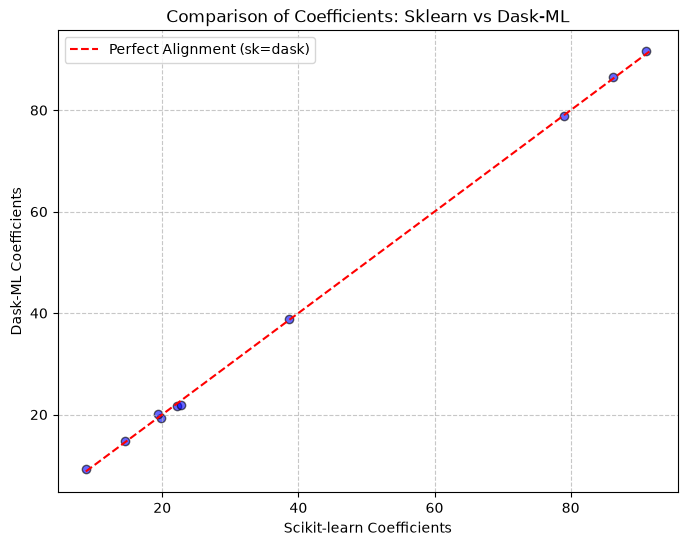

In [ ]:
# Show the results
plot_coefs(sk_mlp_coefs, dask_mlp_coefs)

## Specialized versions of tree algorithms
Specialized `dask` algorithms exist tree-based methods such as `xgboost` and `lightgbm` in those packages. We show how to use it for `xgboost`. 

For this you will have to setup a Dask Distributed client.

In [11]:
#import xgboost as xgb
from xgboost import dask as dxgb

xgb_reg = dxgb.DaskXGBRegressor(n_estimators=100, tree_method="hist", seed=0) #hist is newer and faster
xgb_reg.client = client  # assign the client
_ = xgb_reg.fit(X_train, y_train, eval_set=[(X_train, y_train)])

# Then use! For example,
#xgb_reg.predict(X_test)

References:
- https://examples.dask.org/machine-learning/incremental.html
- https://ml.dask.org/incremental.html

In [12]:
client.shutdown()

In [13]:
# Reproducibility info
import sys, pandas as pd, numpy as np, matplotlib, dask, dask_ml, xgboost
print(f'Python:       {sys.version}')
print(f'NumPy:        {np.__version__}')
print(f'Pandas:       {pd.__version__}')
print(f'Matplotlib:   {matplotlib.__version__}')
print(f'dask: {dask.__version__}')
print(f'dask-ml: {dask_ml.__version__}')
print(f'xgboost: {xgboost.__version__}')

Python:       3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:27:10) [MSC v.1944 64 bit (AMD64)]
NumPy:        2.2.5
Pandas:       2.2.3
Matplotlib:   3.11.0
dask: 2025.1.0
dask-ml: 0.1.dev825+gfcc8111ac
xgboost: 3.2.0
